# Time Series Analysis: Similarity

In [11]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

In [12]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=50, radius=1000000)
station_ids = stations.index.tolist()
print(f"Station IDs: {station_ids}")

start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

ts_data = data.fetch().reset_index().pivot(index='time', columns='station', values='temp').squeeze()

Station IDs: ['16020', '16021', '16014', '16022', '16023', '11128', 'RX7H4', '16008', '6LEC2', '16033', 'LIVE0', '0NXLG', '11126', '9E472', '11322', '0A4ME', '11121', '06778', '11120', '11201', '06798', 'OD56C', '06799', '0P4Z1', '11112', 'B8ZOA', '11134', '11122', '06794', '11312', '16094', '11109', '10961', '4JJZ8', '16098', 'D3307', '16036', 'KQHK0', '16037', '11110', '10963', 'LSZS0', '06792', 'BPG68', 'K4R3K', '16099', '06790', '11204', '06791', '06784']


## 1. Similarity Measures

A lot of time series analysis algorithms depend on the similarity between two time series or subsequences.

### ED
As time series can be understood as a vector with length $n$, this vector would point to a point in $n$-dimensional space. The similarity between two subsequences could then be understood as the straight-line distance between their respective points in space - the euclidian distance (ED).

$$ED(X, Y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

In [91]:
# or use numpy.linalg.norm(a-b)
def euclidean_distance(ts1, ts2):
    # note that "-" and "**" are piecewise operations in numpy
    return np.sqrt(np.sum((ts1 - ts2) ** 2)).astype(float)

The two time series have a euclidean distance of 74.67


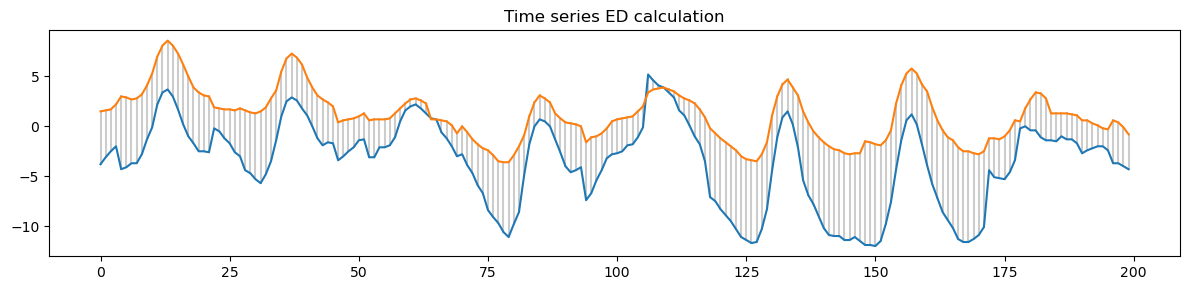

In [92]:
ts_cutoff = 200 # only use part of the data for visibility

# Calculate ED
eucl_dist = euclidean_distance(ts_data.iloc[:ts_cutoff, 0], ts_data.iloc[:ts_cutoff, 1])
print(f"The two time series have a euclidean distance of {eucl_dist:.2f}")

# Plot time series and ED calculation lines
plt.figure(figsize=(12, 3))
plt.title("Time series ED calculation")
for i in range(ts_cutoff):
    plt.plot([i, i], [ts_data.iloc[i, 0], ts_data.iloc[i, 1]], color="gray", alpha=0.4)

plt.plot(ts_data.iloc[:ts_cutoff, :2].values)
plt.tight_layout()
plt.show()

## DTW
However, this approach assumes that both time series are of the same length. Furthermore, a time series could have a high ED to a shifted version of itself, although they can be understood as very similar. 

To solve this, Dynamic Time Warping (DTW) introduces a more "elastic" similarity measure. "Dynamic" because it involves dynamic programming and "Warping" because it can be understood as a distance between warped versions of the time series. It is considered a pseudo-distance / not a true metric because it does not satisfy the triangle inequality. It is always less than or equal to ED.

$$DTW(X,Y) = \min_{\pi \in \mathcal{A}(X, Y)} \left( \sqrt{\sum_{(i,j) \in \pi} (x_i - y_i)^2} \right)$$

with 
- $A(X,Y)$ being the set of all valid paths that map $X$ to $Y$
- $\pi$ looping through the paths
- $(i,j)$ being the paired coordinates on the path mapping $x_i$ to $y_j$

The dynamic programming algorithm creates a path of least distance in a matrix spanned by the two time series from the bottom left $(0,0)$ to the top right $(N,M)$. A field $(x,y)$ in the matrix holds the cumulative distance when the time series is warped in a way that $x$ matches to $y$.

Horizontal/Vertical steps resemble stretching and compressing of the time series (one time series stops while the other advances) while diagonal steps resemble direct matches.

Natively, the algorithm calculates the whole distance matrix. In order to limit the warping to a reasonable level and gaining some speed up, one can specify a so called Sakoe-Chiba-band that limits the number of steps away from the diagonal.

In [93]:
from tslearn.metrics import dtw, dtw_path

def dtw_manual(ts1, ts2, constraint):
    # 1: Variables
    n = len(ts1)
    m = len(ts2)

    w = max(constraint, abs(n-m))
    
    # 2: Matrix Initialization
    C = np.full((n + 1, m + 1), np.inf)
    C[0, 0] = 0

    # 3: Main loop
    for i in range(1, n+1):
        for j in range(max(1, i-w), min(m+1, i+w+1)): # for j in range(1, m+1) without constraint
            dist = (ts1[i-1] - ts2[j-1]) ** 2   # squared ED between data points
            
            C[i, j] = dist + min(C[i-1, j],     # Insertion
                                 C[i, j-1],     # Deletion
                                 C[i-1, j-1]    # Match
                                 )

    return np.sqrt(C[n, m]) # final distance

The two time series have a dynamic time warp distance of 69.95


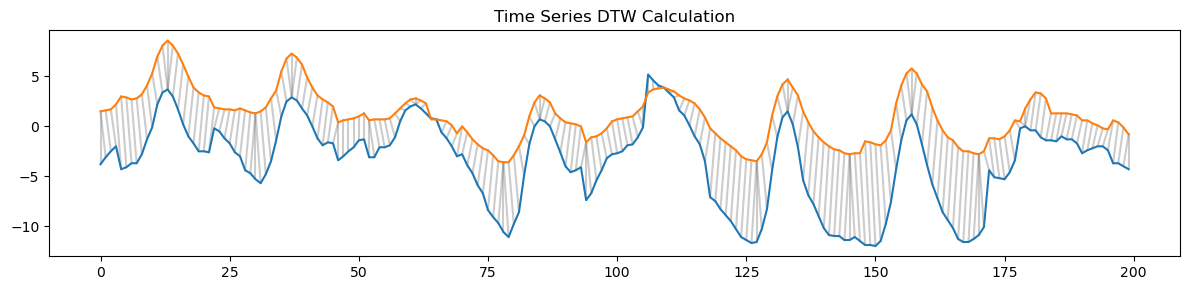

In [94]:
# We are using tslearn as it automatically provides the optimal path
path, dtw_dist = dtw_path(ts_data.iloc[:ts_cutoff, 0].values, ts_data.iloc[:ts_cutoff, 1].values, global_constraint="sakoe_chiba")

print(f"The two time series have a dynamic time warp distance of {dtw_dist:.2f}")

plt.figure(figsize=(12, 3))
plt.title("Time Series DTW Calculation")
for i, j in path:
    plt.plot([i, j], [ts_data.iloc[i, 0], ts_data.iloc[j, 1]], color="gray", alpha=0.4)

plt.plot(ts_data.iloc[:ts_cutoff, :2].values)
plt.tight_layout()
plt.show()

Let's time our code against a library DTW implementation. As DTW is necessaraly in $\mathcal{O}(n^2)$, the results should be within a similar order of magnitude. We can observe how both implementations perfomances grow in a similar manner, while tslearn still being slightly more efficient.

In [95]:
%%time
dist1 = dtw_manual(ts_data["16020"].values, ts_data["16021"].values, constraint=1)

CPU times: user 1.54 s, sys: 2.89 s, total: 4.43 s
Wall time: 4.43 s


In [96]:
%%time
dist2 = dtw(ts_data["16020"].values, ts_data["16021"].values, global_constraint="sakoe_chiba")

CPU times: user 802 ms, sys: 3.06 s, total: 3.87 s
Wall time: 3.84 s


In [97]:
print(f"The two DTW implementations give the same result: {np.isclose(dist1, dist2)}")

The two DTW implementations give the same result: True


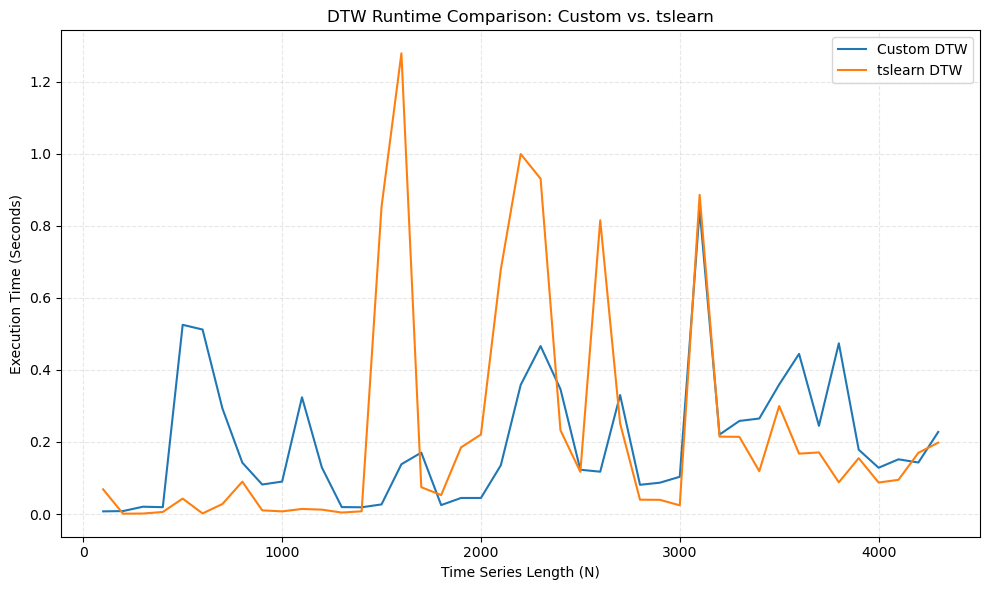

In [98]:
import time

# ==========================================
# 2. Benchmarking Parameters
# ==========================================
max_length, _ = ts_data.shape
max_length //= 2
step_size = 100

# Arrays to store the results
lengths = list(range(100, max_length + 1, step_size))
times_custom = []
times_tslearn = []

# ==========================================
# 3. Execution Loop
# ==========================================
ts1 = ts_data["16020"].values
ts2 = ts_data["16021"].values

for L in lengths:
    # --- Time Custom DTW ---
    start_time = time.perf_counter()
    dtw_manual(ts1[:L], ts2[:L], constraint=1)
    end_time = time.perf_counter()
    times_custom.append(end_time - start_time)
    
    # --- Time tslearn DTW ---
    start_time = time.perf_counter()
    dtw(ts1[:L], ts2[:L], global_constraint="sakoe_chiba")
    end_time = time.perf_counter()
    times_tslearn.append(end_time - start_time)
    
# ==========================================
# 4. Plotting the Results
# ==========================================
plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(lengths, times_custom, label='Custom DTW')
plt.plot(lengths, times_tslearn, label='tslearn DTW')

# Aesthetics
plt.title("DTW Runtime Comparison: Custom vs. tslearn")
plt.xlabel("Time Series Length (N)")
plt.ylabel("Execution Time (Seconds)")
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

## 2. Similarity Search
There are different goals for finding similar time series to a query time series: One can try to find the most similar one (1-NN), the k most similar ones (k-NN) or all being at least $\epsilon$ similar ($\epsilon$-Range Search).

These algorithms follow a similar logic of comparing the distance of the query to every other time series in the set. Different distance metrics can trivially yield different similarity results, but do not influence the algorithms themselves.

We implement k-NN search here:

In [117]:
import heapq

def knn_search(query_ts, ts_set, k, distance_measure):
    # 1: Initialization
    heap = []
    max_dist = np.inf

    # 2: Loop through set of candidate time series
    for i, ts in enumerate(ts_set.T):
        # 2.1: Determine distance of query to candidate
        if distance_measure == "DTW":
            dist = dtw(query_ts, ts)
        else:
            dist = euclidean_distance(query_ts, ts)

        # 2.2: Collecting k time series
        if len(heap) < k:
            heapq.heappush_max(heap, (dist, i))

            if len(heap) == k:
                max_dist = heap[0][0]

        # 2.3: Swap more similar time series with most distant in current knn list
        elif dist < max_dist:
            heapq.heappushpop_max(heap, (dist, i))
            max_dist = heap[0][0]

    return heapq.nsmallest(k, heap)

ED 4-NN distances: [(np.float64(54.357612162419336), 3), (np.float64(66.25888619649442), 35), (np.float64(104.27756230369026), 6), (np.float64(104.47420734324807), 14)]
DTW 4-NN distances: [(32.3675763689529, 3), (35.10612482174584, 35), (59.5457807069485, 27), (61.08494086106659, 19)]


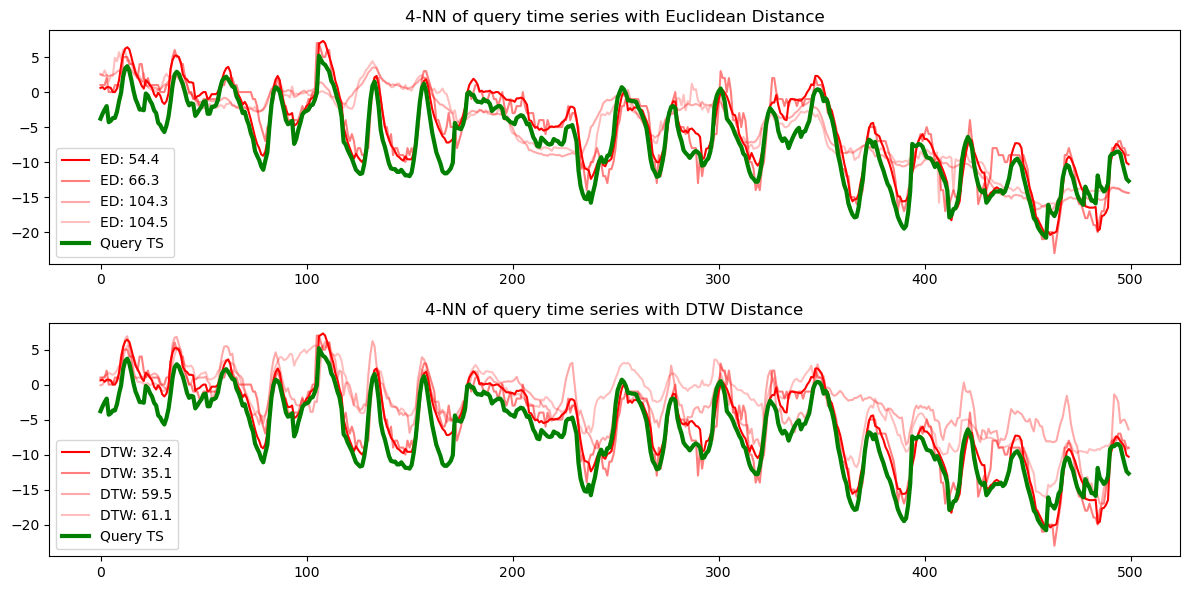

In [122]:
# Specify parameters
ts_cutoff = 500
query_ts = ts_data.iloc[:ts_cutoff, 0].values
ts_set = ts_data.iloc[:ts_cutoff, 1:].values
k = 4

# Collect kNN
knn_ed = sorted(knn_search(query_ts, ts_set, k, "ED"))
knn_dtw = sorted(knn_search(query_ts, ts_set, k, "DTW"))

print(f"ED {k}-NN distances: {knn_ed}")
print(f"DTW {k}-NN distances: {knn_dtw}")

# Plot against query time series
plt.figure(figsize=(12, 6))
for i in range(k):
    plt.subplot(2, 1, 1)
    plt.plot(ts_data.iloc[:ts_cutoff, knn_ed[i][1] + 1].values, color="red", alpha=1.0/(i+1), label=f"ED: {knn_ed[i][0]:.1f}")

    plt.subplot(2, 1, 2)
    plt.plot(ts_data.iloc[:ts_cutoff, knn_dtw[i][1] + 1].values, color="red", alpha=1.0/(i+1), label=f"DTW: {knn_dtw[i][0]:.1f}")

plt.subplot(2, 1, 1)
plt.title(f"{k}-NN of query time series with Euclidean Distance")
plt.plot(query_ts, lw=3, color="green", label="Query TS")
plt.legend()

plt.subplot(2, 1, 2)
plt.title(f"{k}-NN of query time series with DTW Distance")
plt.plot(query_ts, lw=3, color="green", label="Query TS")
plt.legend()

plt.tight_layout()
plt.show()

## 3. Lower Bounding

In order to compute the distances more efficiently, lower bounding provides fast skimming of candidate time series that are definetily not similar enough without calculating the entire distance.

Especially for DTW which operates in $\mathcal{O}(n^2)$ this can provide a massive speed up. By far the most popular lower bounding method for DTW is called lb_koegh. It creates an envelope with an upper edge $U$ and lower edge $L$ around the query and calculates the euclidean distance to this envelope. It holds that
$$DTW(Q, C) \ge LB\_Koegh(Q, C) = \sum_{i=1}^n \begin{cases} (q_i - U_i)^2 & \text{if}\ q_i > U_i \\ (q_i - L_i)^2 & \text{if}\ q_i < L_i \\ 0 & \text{otherwise}\end{cases}$$

We are showing lower bounding in combination with the $\epsilon$-Range search algorithm. If the lower bound distance is already bigger than $\epsilon$, the DTW will be as well. Thus, we do not have to evaluate the respective candidate further:

In [101]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import dtw, lb_keogh

def lower_bound_search(ts_query, ts_set, epsilon, use_lb=True):
    # 1: Initalization
    results = []
    znorm = TimeSeriesScalerMeanVariance() # using tslearn for consistency instead of scipy
    ts_query_normed = znorm.fit_transform(ts_query.reshape(1, -1)).flatten()

    # 2: Loop through candidate set
    for i, ts in enumerate(ts_set.T):
        ts_normed = znorm.fit_transform(ts.reshape(1, -1)).flatten() # LB_Koegh requires normalized data

        if use_lb:
            # 2.1: Skip candidate if lower bound is bigger than epsilon
            lb_dist = lb_keogh(ts_query_normed, ts_normed)

            if lb_dist > epsilon:
                continue
        
        # 2.2: Only calculate dtw if it could be within epsilon range
        exact_dist = dtw(ts_query_normed, ts_normed, global_constraint="sakoe_chiba")

        if exact_dist <= epsilon:
            results.append((exact_dist, i))
    
    return results

/home/moritz/miniconda3/envs/unibz-tsa-examples/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Lets time the lower bounding and make a sanity check whether it leads to equal results:

In [102]:
%%time
results_lb_on = lower_bound_search(ts_data["16020"].values, ts_data[ts_data.columns[ts_data.columns != "16020"]].values, 40, use_lb=True)

CPU times: user 18.7 s, sys: 8.33 s, total: 27.1 s
Wall time: 26.5 s


In [103]:
%%time
results_lb_off = lower_bound_search(ts_data["16020"].values, ts_data[ts_data.columns[ts_data.columns != "16020"]].values, 40, use_lb=False)

CPU times: user 6.31 s, sys: 6.76 s, total: 13.1 s
Wall time: 13 s


In [104]:
print(f"The LB result is equal: {results_lb_off == results_lb_on}")

The LB result is equal: True


## Exercises

Implement the improved euclidean distance computation

Implement l2 distance or pearson correlation as a distance measure. Compare it to ED and dtw